<a href="https://colab.research.google.com/github/coopster-seclusion/GISC401_Cass_Project/blob/main/GISC401_Westport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This document is a pointer and you mays choose to work with the data using different libraries and methods. That is completely fine, as long as they make sense and you can explain what you did. This document doe snot have many comments on purpose. This is self-directed learning and  with help of manuals,  the general descriptions here, your group should be able to understand the code and add your own comments.

# **1 - Connecting to Google Drive to access data**


In [ ]:
from google.colab import drive

In [ ]:
#Vanessa to use her UC Gmail Drive
drive.mount('/content/GDrive')

Mounted at /content/GDrive


**2 - Converting GPX files to pandas DataFrames**

In [ ]:
!pip install gpxpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os

In [ ]:
# List comprehension to filter only .gpx files
gpx_files = [gpx_file for gpx_file in os.listdir("/content/GDrive/MyDrive/GISC401/GPX_traces") if gpx_file.endswith('.gpx')]

In [ ]:
os.getcwd()

'/content'

In [ ]:
os.chdir('/content/GDrive/MyDrive/GISC401/GPX_traces')

In [ ]:
os.getcwd()

'/content/GDrive/MyDrive/GISC401/GPX_traces'

In [ ]:
gpx_files[0]

'H.gpx'

In [ ]:
import gpxpy
import pandas as pd

# Load gpx.
gpx_path = gpx_files[0]
with open(gpx_path) as f:
    gpx = gpxpy.parse(f)

# Convert to a dataframe one point at a time.
points = []
for segment in gpx.tracks[0].segments:
    for p in segment.points:
        points.append({
            'time': p.time,
            'latitude': p.latitude,
            'longitude': p.longitude,
            'elevation': p.elevation,
        })

track_df = pd.DataFrame.from_records(points)

In [ ]:
gpx

GPX(tracks=[GPXTrack(name='2026-03-15 AM 07:41:31', segments=[GPXTrackSegment(points=[...])])])

In [ ]:
gpx.tracks[0].segments

[GPXTrackSegment(points=[...])]

In [ ]:
segment

GPXTrackSegment(points=[...])

In [ ]:
segment.points

In [ ]:
points

In [ ]:
track_df

,time,latitude,longitude,elevation
0,2026-03-14 18:41:31.361000+00:00,-43.520005,172.582523,10.485683
1,2026-03-14 18:41:32.361000+00:00,-43.519866,172.582408,17.035366
2,2026-03-14 18:41:33.594000+00:00,-43.519799,172.582279,15.048422
3,2026-03-14 18:41:34.771000+00:00,-43.519710,172.582148,15.681672
4,2026-03-14 18:41:36.500000+00:00,-43.519638,172.581969,15.141918
...,...,...,...,...
395,2026-03-14 21:40:48.502000+00:00,-43.034829,171.759081,574.210951
396,2026-03-14 21:41:24.560000+00:00,-43.034938,171.759565,577.319214
397,2026-03-14 21:41:58+00:00,-43.034956,171.759543,577.381067
398,2026-03-14 21:43:31+00:00,-43.034761,171.759470,579.231368


In [ ]:
gpx_files[0].split('.')[0]

'H'

In [ ]:
track_df['Name'] = gpx_files[0].split('.')[0]

In [ ]:
track_df.head(3)

,time,latitude,longitude,elevation,Name
0,2026-03-14 18:41:31.361000+00:00,-43.520005,172.582523,10.485683,H
1,2026-03-14 18:41:32.361000+00:00,-43.519866,172.582408,17.035366,H
2,2026-03-14 18:41:33.594000+00:00,-43.519799,172.582279,15.048422,H


In [ ]:
track_df.dtypes

,0
time,"datetime64[ns, SimpleTZ('Z')]"
latitude,float64
longitude,float64
elevation,float64
Name,object


In [ ]:
# Convert the timestamp column to datetime
track_df['timestamp'] = pd.to_datetime(track_df['time'])

In [ ]:
track_df

,time,latitude,longitude,elevation,Name,timestamp
0,2026-03-14 18:41:31.361000+00:00,-43.520005,172.582523,10.485683,H,2026-03-14 18:41:31.361000+00:00
1,2026-03-14 18:41:32.361000+00:00,-43.519866,172.582408,17.035366,H,2026-03-14 18:41:32.361000+00:00
2,2026-03-14 18:41:33.594000+00:00,-43.519799,172.582279,15.048422,H,2026-03-14 18:41:33.594000+00:00
3,2026-03-14 18:41:34.771000+00:00,-43.519710,172.582148,15.681672,H,2026-03-14 18:41:34.771000+00:00
4,2026-03-14 18:41:36.500000+00:00,-43.519638,172.581969,15.141918,H,2026-03-14 18:41:36.500000+00:00
...,...,...,...,...,...,...
395,2026-03-14 21:40:48.502000+00:00,-43.034829,171.759081,574.210951,H,2026-03-14 21:40:48.502000+00:00
396,2026-03-14 21:41:24.560000+00:00,-43.034938,171.759565,577.319214,H,2026-03-14 21:41:24.560000+00:00
397,2026-03-14 21:41:58+00:00,-43.034956,171.759543,577.381067,H,2026-03-14 21:41:58+00:00
398,2026-03-14 21:43:31+00:00,-43.034761,171.759470,579.231368,H,2026-03-14 21:43:31+00:00


In [ ]:
# Format the timestamp column
track_df['timestamp'] = track_df['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [ ]:
track_df

,time,latitude,longitude,elevation,Name,timestamp
0,2026-03-14 18:41:31.361000+00:00,-43.520005,172.582523,10.485683,H,2026-03-14 18:41:31
1,2026-03-14 18:41:32.361000+00:00,-43.519866,172.582408,17.035366,H,2026-03-14 18:41:32
2,2026-03-14 18:41:33.594000+00:00,-43.519799,172.582279,15.048422,H,2026-03-14 18:41:33
3,2026-03-14 18:41:34.771000+00:00,-43.519710,172.582148,15.681672,H,2026-03-14 18:41:34
4,2026-03-14 18:41:36.500000+00:00,-43.519638,172.581969,15.141918,H,2026-03-14 18:41:36
...,...,...,...,...,...,...
395,2026-03-14 21:40:48.502000+00:00,-43.034829,171.759081,574.210951,H,2026-03-14 21:40:48
396,2026-03-14 21:41:24.560000+00:00,-43.034938,171.759565,577.319214,H,2026-03-14 21:41:24
397,2026-03-14 21:41:58+00:00,-43.034956,171.759543,577.381067,H,2026-03-14 21:41:58
398,2026-03-14 21:43:31+00:00,-43.034761,171.759470,579.231368,H,2026-03-14 21:43:31


In [ ]:
track_df.to_csv('/content/GDrive/MyDrive/GISC401/GPX_traces/Results/H.csv')

In [ ]:
!pip install movingpandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 4.4 MB/s eta 0:00:00


https://github.com/movingpandas/movingpandas-examples/tree/main

In [ ]:
import movingpandas as mpd

/usr/local/lib/python3.12/dist-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [ ]:
traj_collection = mpd.TrajectoryCollection(track_df, 'Name', t='timestamp', x='longitude', y='latitude')
print(traj_collection)

TrajectoryCollection with 1 trajectories


In [ ]:
my_traj = traj_collection.trajectories[0]
print(my_traj)

Trajectory H (2026-03-14 18:41:31 to 2026-03-14 21:44:21) | Size: 395 | Length: 123114.6m
Bounds: (171.7071838127945, -43.53031106111457, 172.5825231870211, -43.03418332474873)
LINESTRING (172.5825231870211 -43.52000488581133, 172.5824079609093 -43.5198657413672, 172.582278617


<Axes: >

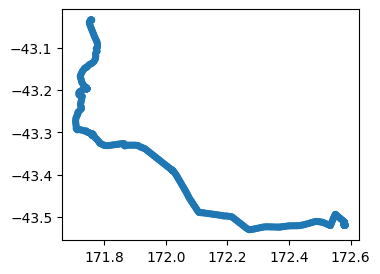

In [ ]:
my_traj.plot(linewidth=5, capstyle='round', figsize=(9,3))

In [ ]:
!pip install hvplot -q
!pip install geoviews -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 46.2 MB/s eta 0:00:00


In [ ]:
my_traj.hvplot(line_width=7.0, tiles='OSM')

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (triangle_angle)

In [ ]:
detector = mpd.TrajectoryStopDetector(my_traj)

In [ ]:
from datetime import datetime, timedelta

stop_time_ranges = detector.get_stop_time_ranges(min_duration=timedelta(seconds=60), max_diameter=100)

In [ ]:
for x in stop_time_ranges:
    print(x)

Traj H: 2026-03-14 19:28:51 - 2026-03-14 20:00:40 (duration: 0 days 00:31:49)
Traj H: 2026-03-14 20:40:50 - 2026-03-14 20:49:40 (duration: 0 days 00:08:50)
Traj H: 2026-03-14 20:50:10 - 2026-03-14 20:51:10 (duration: 0 days 00:01:00)
Traj H: 2026-03-14 20:51:40 - 2026-03-14 20:57:41 (duration: 0 days 00:06:01)
Traj H: 2026-03-14 20:58:10 - 2026-03-14 20:59:12 (duration: 0 days 00:01:02)
Traj H: 2026-03-14 20:59:42 - 2026-03-14 21:01:12 (duration: 0 days 00:01:30)
Traj H: 2026-03-14 21:01:45 - 2026-03-14 21:06:23 (duration: 0 days 00:04:38)
Traj H: 2026-03-14 21:07:14 - 2026-03-14 21:09:48 (duration: 0 days 00:02:34)
Traj H: 2026-03-14 21:10:18 - 2026-03-14 21:19:29 (duration: 0 days 00:09:11)
Traj H: 2026-03-14 21:38:18 - 2026-03-14 21:39:18 (duration: 0 days 00:01:00)
Traj H: 2026-03-14 21:40:48 - 2026-03-14 21:44:21 (duration: 0 days 00:03:33)


In [ ]:
stop_points = detector.get_stop_points(min_duration=timedelta(seconds=60), max_diameter=100)

In [ ]:
traj_plot = my_traj.hvplot(title='Trajectory {}'.format(my_traj.id), line_width=7.0, tiles='CartoLight', color='slategray')
traj_plot

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Path.I   :Path   [Longitude,Latitude]
   .Points.I :Points   [Longitude,Latitude]   (triangle_angle)

In [ ]:
stop_point_plot = traj_plot * stop_points.hvplot(geo=True, size='duration_s', color='deeppink')

In [ ]:
%env HV_DOC_HTML=true

env: HV_DOC_HTML=true


In [ ]:
import holoviews as hv

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
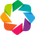

:Overlay
   .WMTS.I    :WMTS   [Longitude,Latitude]
   .Path.I    :Path   [Longitude,Latitude]
   .Points.I  :Points   [Longitude,Latitude]   (triangle_angle)
   .Points.II :Points   [Longitude,Latitude]   (duration_s)

In [ ]:
hv.extension('bokeh')
stop_point_plot

<Axes: >

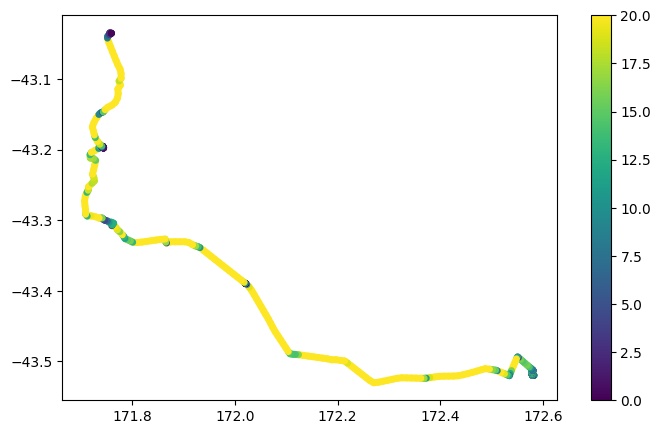

In [ ]:
traj_collection.plot(column='speed', linewidth=5, capstyle='round', legend=True, vmax=20, figsize=(9,5))

In [ ]:
traj_collection.add_speed(overwrite=True)

TrajectoryCollection with 1 trajectories

In [ ]:
import numpy as np
speed=[]
for traj in traj_collection.trajectories:
  speed.append((traj.df.speed.values))

In [ ]:
len(speed)

1

In [ ]:
speed

[array([1.80493767e+01, 1.80493767e+01, 1.28462455e+01, 1.44485635e+01,
        8.26434286e+00, 7.20758994e+00, 7.42431834e+00, 8.17797112e+00,
        8.17832530e+00, 8.58578008e+00, 8.07346840e+00, 8.57994656e+00,
        8.72103496e+00, 1.00175078e+01, 1.02952484e+01, 9.92355191e+00,
        9.58943597e+00, 8.74018682e+00, 8.79143106e+00, 8.20176971e+00,
        8.44972835e+00, 8.68846584e+00, 8.42394138e+00, 8.55647205e+00,
        7.94466072e+00, 7.10030709e+00, 6.57915325e+00, 5.39434109e+00,
        5.20429056e+00, 5.01474767e+00, 1.01505749e+00, 1.33008527e+00,
        2.56718723e+00, 3.50806340e+00, 3.84568202e+00, 4.26978091e+00,
        4.45636642e+00, 5.13233463e+00, 5.74808514e+00, 6.51105042e+00,
        6.86839468e+00, 7.55196482e+00, 6.15883227e+00, 1.53340927e+01,
        9.07325600e+00, 1.10414654e+01, 5.60747218e+00, 1.65206269e+01,
        1.32575585e+01, 6.60310967e+00, 1.29394318e+01, 1.27761275e+01,
        9.65077492e+00, 1.01243862e+01, 5.63224436e+00, 9.529045

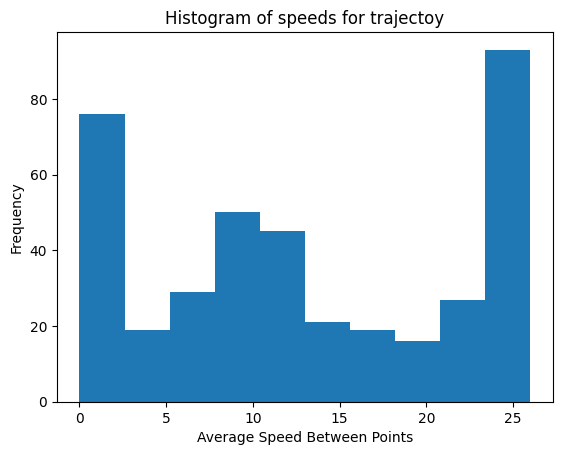

In [ ]:
import matplotlib.pyplot as plt

plt.hist(speed, density=False)
plt.title('Histogram of speeds for trajectoy')
plt.xlabel('Average Speed Between Points')
plt.ylabel('Frequency')
plt.show()

https://anitagraser.com/movingpandas/

In [ ]:
traj_collection.add_distance(overwrite=True, name='dist')
traj_collection.add_timedelta(overwrite=True, name='td')

TrajectoryCollection with 1 trajectories

In [ ]:
dist=[]
for traj in traj_collection.trajectories:
  dist.append((traj.df.dist.values))

In [ ]:
dist

[array([0.00000000e+00, 1.80493767e+01, 1.28462455e+01, 1.44485635e+01,
        1.65286857e+01, 7.20758994e+00, 7.42431834e+00, 8.17797112e+00,
        8.17832530e+00, 8.58578008e+00, 8.07346840e+00, 8.57994656e+00,
        8.72103496e+00, 1.00175078e+01, 1.02952484e+01, 9.92355191e+00,
        9.58943597e+00, 8.74018682e+00, 8.79143106e+00, 8.20176971e+00,
        8.44972835e+00, 8.68846584e+00, 8.42394138e+00, 8.55647205e+00,
        7.94466072e+00, 7.10030709e+00, 6.57915325e+00, 5.39434109e+00,
        5.20429056e+00, 5.01474767e+00, 2.03011499e+00, 2.12813643e+01,
        5.13437447e+00, 3.50806340e+00, 3.84568202e+00, 4.26978091e+00,
        4.45636642e+00, 5.13233463e+00, 5.74808514e+00, 6.51105042e+00,
        6.86839468e+00, 7.55196482e+00, 1.23176645e+01, 1.53340927e+01,
        9.07325600e+00, 1.10414654e+01, 1.12149444e+01, 1.65206269e+01,
        1.32575585e+01, 1.32062193e+01, 1.29394318e+01, 1.27761275e+01,
        9.65077492e+00, 1.01243862e+01, 1.12644887e+01, 9.529045

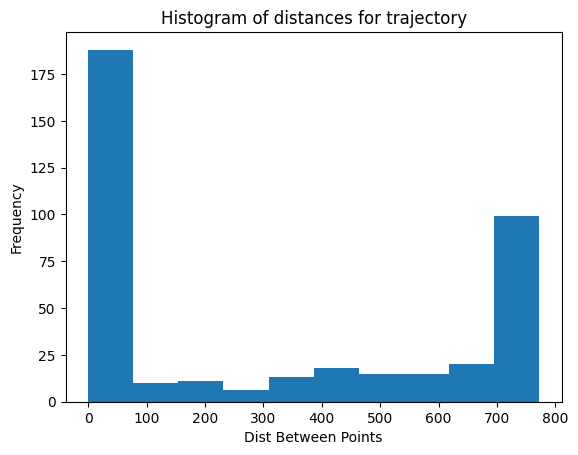

In [ ]:
import matplotlib.pyplot as plt

plt.hist(dist, density=False)
plt.title('Histogram of distances for trajectory')
plt.xlabel('Dist Between Points')
plt.ylabel('Frequency')
plt.show()

In [ ]:
td=[]

from datetime import datetime

for traj in traj_collection.trajectories:
  td.append((traj.df.td.dt.seconds.values))

In [ ]:
td

[array([ nan,   1.,   1.,   1.,   2.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,  16.,   2.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,   1.,
          1.,   1.,   2.,   1.,   1.,   2.,   1.,   1.,   1.,   1.,   2.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   2.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,   1.,   1.,
          1.,   1.,   2.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   2.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   2.,   1.,   1.,   1.,   1.,   2.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,  30.,  31.,  30.,  30.,  30.,  30.,
         30.,  30.,  43.,  30.,  30.,  31.,  30.,  30.,  30.,  31.,  30.,
         30.,  30.,  30.,  30.,  31.,  30.,  30.,  30.,  31.,  30.,  30.,
         30.,  30.,  31.,  29.,  31., 

In [ ]:
import pandas as pd
pd.unique(td[0])

array([ nan,   1.,   2.,  16.,  30.,  31.,  43.,  29.,  32., 117.,  80.,
       174., 406., 197., 311.,  35.,  92.,  56.,  47.,  95., 142.,  46.,
       258.,  72.,  51.,  97.,  33., 119.,  36., 156.,  53.,  41.,  34.,
        93.,  50.])

In [ ]:
# Using a dictionary to count the frequency of each value
values = td[0]

# Count the frequency of each value using a dictionary
frequency_dict = {}
for value in values:
    if value in frequency_dict:
        frequency_dict[value] += 1
    else:
        frequency_dict[value] = 1

# Output the frequencies
for key, count in frequency_dict.items():
    print(f"The frequency of {key} is: {count}")

# Compute the mode (value with highest frequency)
mode_value = max(frequency_dict, key=frequency_dict.get)
print(f"\nThe mode (most frequent value) is: {mode_value}")

The frequency of nan is: 1
The frequency of 1.0 is: 100
The frequency of 2.0 is: 13
The frequency of 16.0 is: 1
The frequency of 30.0 is: 175
The frequency of 31.0 is: 53
The frequency of 43.0 is: 1
The frequency of 29.0 is: 15
The frequency of 32.0 is: 3
The frequency of 117.0 is: 1
The frequency of 80.0 is: 1
The frequency of 174.0 is: 2
The frequency of 406.0 is: 1
The frequency of 197.0 is: 1
The frequency of 311.0 is: 1
The frequency of 35.0 is: 3
The frequency of 92.0 is: 2
The frequency of 56.0 is: 1
The frequency of 47.0 is: 2
The frequency of 95.0 is: 1
The frequency of 142.0 is: 1
The frequency of 46.0 is: 1
The frequency of 258.0 is: 1
The frequency of 72.0 is: 1
The frequency of 51.0 is: 2
The frequency of 97.0 is: 1
The frequency of 33.0 is: 1
The frequency of 119.0 is: 1
The frequency of 36.0 is: 2
The frequency of 156.0 is: 1
The frequency of 53.0 is: 1
The frequency of 41.0 is: 1
The frequency of 34.0 is: 1
The frequency of 93.0 is: 1
The frequency of 50.0 is: 1

The mo